# **Read DataSet**

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kagle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import spacy
import scipy

from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.linear_model import Lasso , Ridge
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.preprocessing import MinMaxScaler , StandardScaler , RobustScaler 
from sklearn.preprocessing import LabelEncoder , OneHotEncoder
from sklearn.metrics import r2_score , mean_squared_error

import warnings 
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("/kaggle/input/datasets/jahnavikachhia23/texas-residential-real-estate-intelligence-2026/Texas_Residential_Real Estate_Intelligenc_ 2026.csv")
df

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,Price_Per_SqFt
0,single_family,NaN,Experience The Best Of North Texas Living In T...,499000.0,2040.0,2.0,3.0,3.0,2.0,2.0,2.0,2021.0,244.61
1,single_family,NaN,"Welcome home to [Redacted Entity], [Redacted E...",494500.0,3674.0,2.0,6.0,4.0,3.0,3.0,NaN,2025.0,134.59
2,single_family,NaN,Welcome to this beautiful home located in [Red...,229000.0,1650.0,2.0,3.0,3.0,2.0,2.0,2.0,2020.0,138.79
3,single_family,NaN,"Welcome to [Redacted Entity] - where style, co...",260000.0,1741.0,1.0,3.0,2.0,2.0,2.0,2.0,2005.0,149.34
4,single_family,single family detached,***READY NOW*** Discover this stunning new con...,334990.0,2255.0,2.0,4.0,4.0,3.0,3.0,2.0,2025.0,148.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12132,condos,condo,Welcome to [Redacted Entity] in the Heart of [...,222000.0,1495.0,2.0,2.0,3.0,2.0,2.0,NaN,1968.0,148.49
12133,single_family,NaN,Welcome home to this charming farmhouse-style ...,459900.0,2414.0,2.0,4.0,3.0,2.0,2.0,2.0,2021.0,190.51
12134,single_family,NaN,"Welcome to [Redacted Entity], a beautifully ma...",405000.0,3428.0,2.0,4.0,4.0,3.0,3.0,2.0,1984.0,118.14
12135,single_family,NaN,BEACHSIDE GEM HAS IT ALL! Lovely 3/2 in the he...,399000.0,1260.0,1.0,3.0,2.0,2.0,2.0,1.0,2008.0,316.67


# **EDA** 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12137 entries, 0 to 12136
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   type             12137 non-null  object 
 1   sub_type         1749 non-null   object 
 2   text             12137 non-null  object 
 3   listPrice        12134 non-null  float64
 4   sqft             12073 non-null  float64
 5   stories          11630 non-null  float64
 6   beds             12009 non-null  float64
 7   baths            11863 non-null  float64
 8   baths_full       11988 non-null  float64
 9   baths_full_calc  11991 non-null  float64
 10  garage           10224 non-null  float64
 11  year_built       9849 non-null   float64
 12  Price_Per_SqFt   12135 non-null  float64
dtypes: float64(10), object(3)
memory usage: 1.2+ MB


In [5]:
df.describe()

,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,Price_Per_SqFt
count,1.213400e+04,12073.000000,11630.000000,12009.000000,11863.000000,11988.000000,11991.000000,10224.000000,9849.000000,12135.000000
mean,4.998792e+05,2286.140230,1.442562,3.611791,2.882660,2.475142,2.480527,2.134390,2013.043050,208.948589
std,5.409439e+05,1048.659141,0.549794,1.014476,1.191023,0.917721,0.915769,0.605927,22.132438,139.697072
min,8.500000e+02,240.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1654.000000,0.000000
25%,2.880922e+05,1640.000000,1.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2015.000000,154.915000
50%,3.749000e+05,2085.000000,1.000000,4.000000,3.000000,2.000000,2.000000,2.000000,2023.000000,182.910000
75%,5.390000e+05,2686.000000,2.000000,4.000000,3.000000,3.000000,3.000000,2.000000,2025.000000,220.840000
max,1.199500e+07,19600.000000,7.000000,29.000000,39.000000,26.000000,26.000000,20.000000,2028.000000,6363.980000


In [6]:
df.isnull().sum()

type                   0
sub_type           10388
text                   0
listPrice              3
sqft                  64
stories              507
beds                 128
baths                274
baths_full           149
baths_full_calc      146
garage              1913
year_built          2288
Price_Per_SqFt         2
dtype: int64

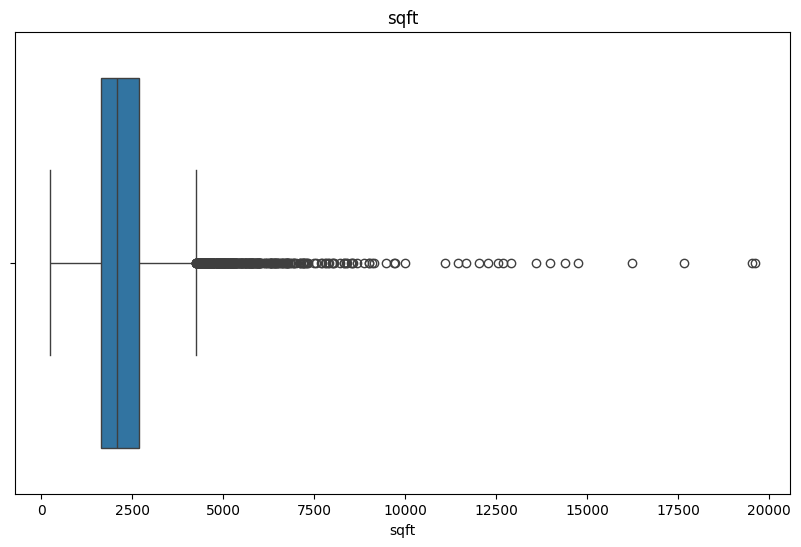

In [7]:
plt.figure(figsize=(10,6))
sns.boxplot(df , x='sqft')
plt.title("sqft")
plt.show()

In [8]:
df[df['sqft'] >= 17500]

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,Price_Per_SqFt
4098,multi_family,NaN,"[Redacted Entity], designed by the creative co...",5500000.0,17647.0,3.0,NaN,0.0,NaN,NaN,NaN,2023.0,311.67
4501,single_family,NaN,"Listed less than recent appraisal, this Downto...",1450000.0,19600.0,2.0,3.0,4.0,3.0,3.0,12.0,1967.0,73.98
8946,multi_family,NaN,This modern 13-unit townhome community was bui...,5577000.0,19541.0,3.0,26.0,39.0,26.0,26.0,2.0,2016.0,285.40


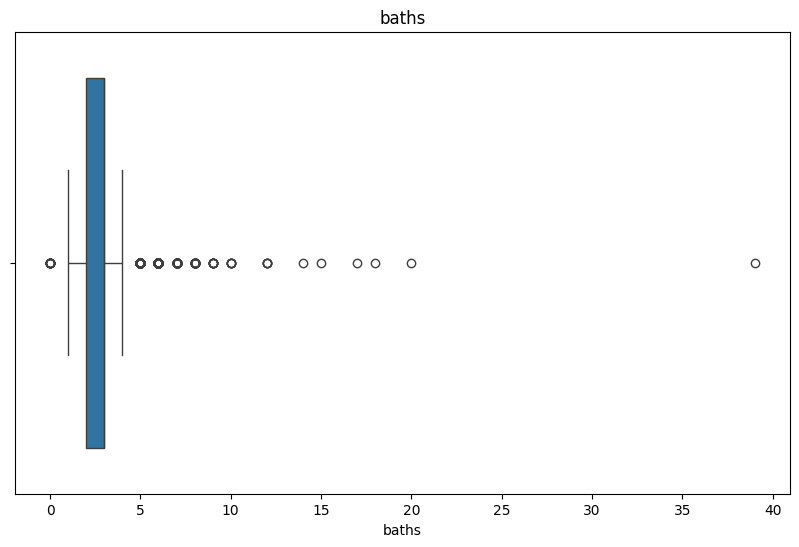

In [9]:
plt.figure(figsize=(10,6))
sns.boxplot(df , x='baths')
plt.title("baths")
plt.show()

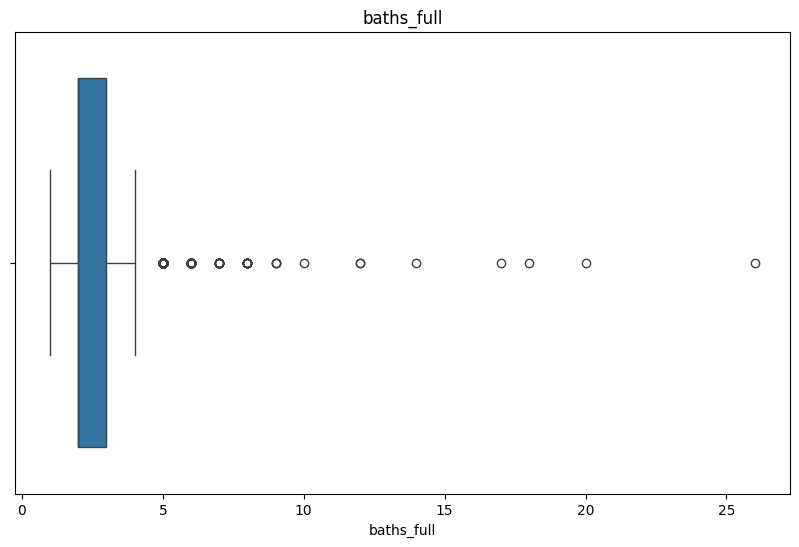

In [10]:
plt.figure(figsize=(10,6))
sns.boxplot(df , x='baths_full')
plt.title("baths_full")
plt.show()

In [11]:
df[df['baths'] >= 25]

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,Price_Per_SqFt
8946,multi_family,NaN,This modern 13-unit townhome community was bui...,5577000.0,19541.0,3.0,26.0,39.0,26.0,26.0,2.0,2016.0,285.4


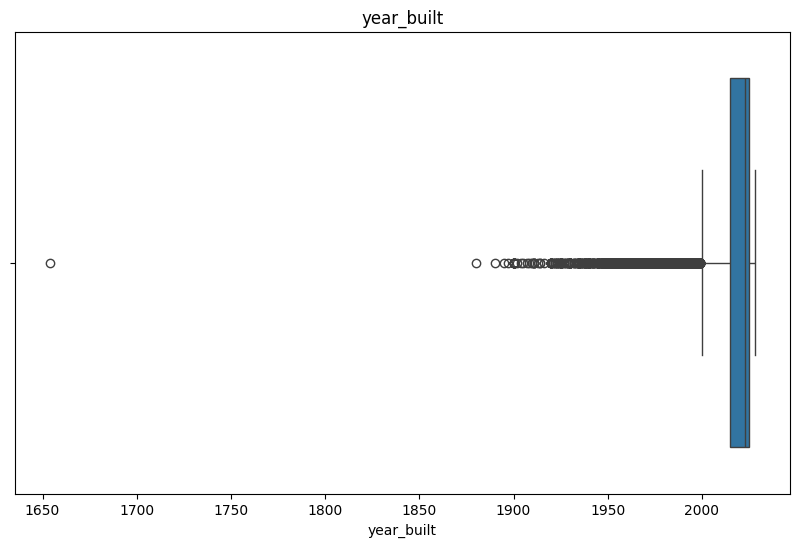

In [12]:
plt.figure(figsize=(10,6))
sns.boxplot(df , x='year_built')
plt.title("year_built")
plt.show()

In [13]:
df[df['year_built'] >= 2028]

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,Price_Per_SqFt
902,condos,condo,Upgrade Credit Incentives! Welcome to a remark...,699000.0,1069.0,1.0,2.0,2.0,2.0,2.0,2.0,2028.0,653.88
3277,condos,condo,"The St. Regis Residences, [Redacted Entity] - ...",4595000.0,2306.0,NaN,3.0,4.0,3.0,3.0,NaN,2028.0,1992.63


In [14]:
df[df['year_built'] <= 1850]

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,Price_Per_SqFt
9719,single_family,NaN,Check out this charming American classic in th...,249900.0,2626.0,1.0,3.0,2.0,2.0,2.0,2.0,1654.0,95.16


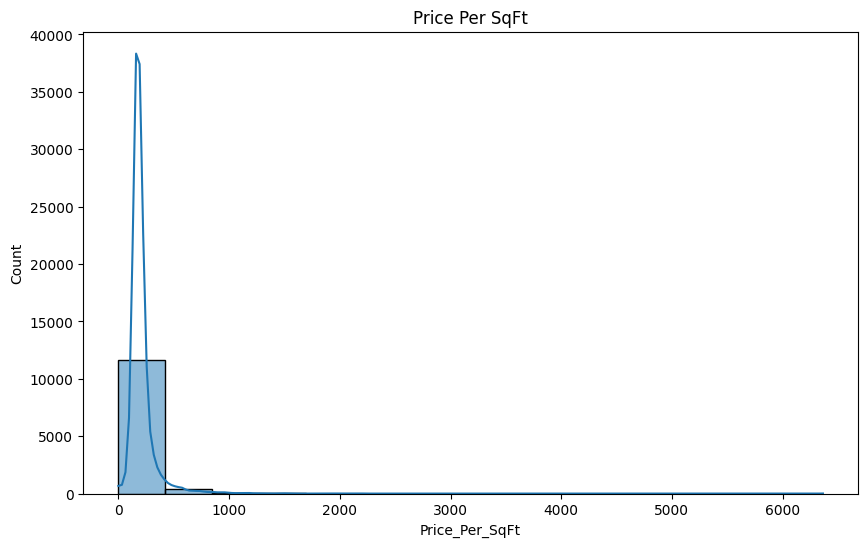

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(df , x='Price_Per_SqFt' , kde=True , bins=15)
plt.title("Price Per SqFt")
plt.show()

In [16]:
df[df['Price_Per_SqFt'] >= 2000]

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,Price_Per_SqFt
4411,condos,condo,"The [Redacted Entity], The Woodlands offer exq...",5621000.0,2555.0,NaN,3.0,4.0,3.0,3.0,NaN,NaN,2200.00
5024,single_family,NaN,[Redacted Entity] is a legacy property that ep...,11900000.0,3495.0,NaN,5.0,5.0,4.0,4.0,NaN,2023.0,3404.86
7304,condos,condo,The West Harbour Villas & Marina is an exclusi...,8995000.0,4383.0,3.0,3.0,4.0,3.0,3.0,2.0,2025.0,2052.25
9693,multi_family,NaN,5.97+/-acres situated between Old Hwy 59 [Reda...,3900051.0,1840.0,1.0,3.0,2.0,2.0,2.0,NaN,1970.0,2119.59
9802,single_family,NaN,"Rare Natural Water Grotto, [Redacted Entity], ...",5371200.0,844.0,1.0,1.0,1.0,1.0,1.0,NaN,1940.0,6363.98
9882,single_family,NaN,Rare opportunity in [Redacted Entity]. One of ...,7999302.0,2816.0,1.0,5.0,4.0,4.0,4.0,2.0,1964.0,2840.66


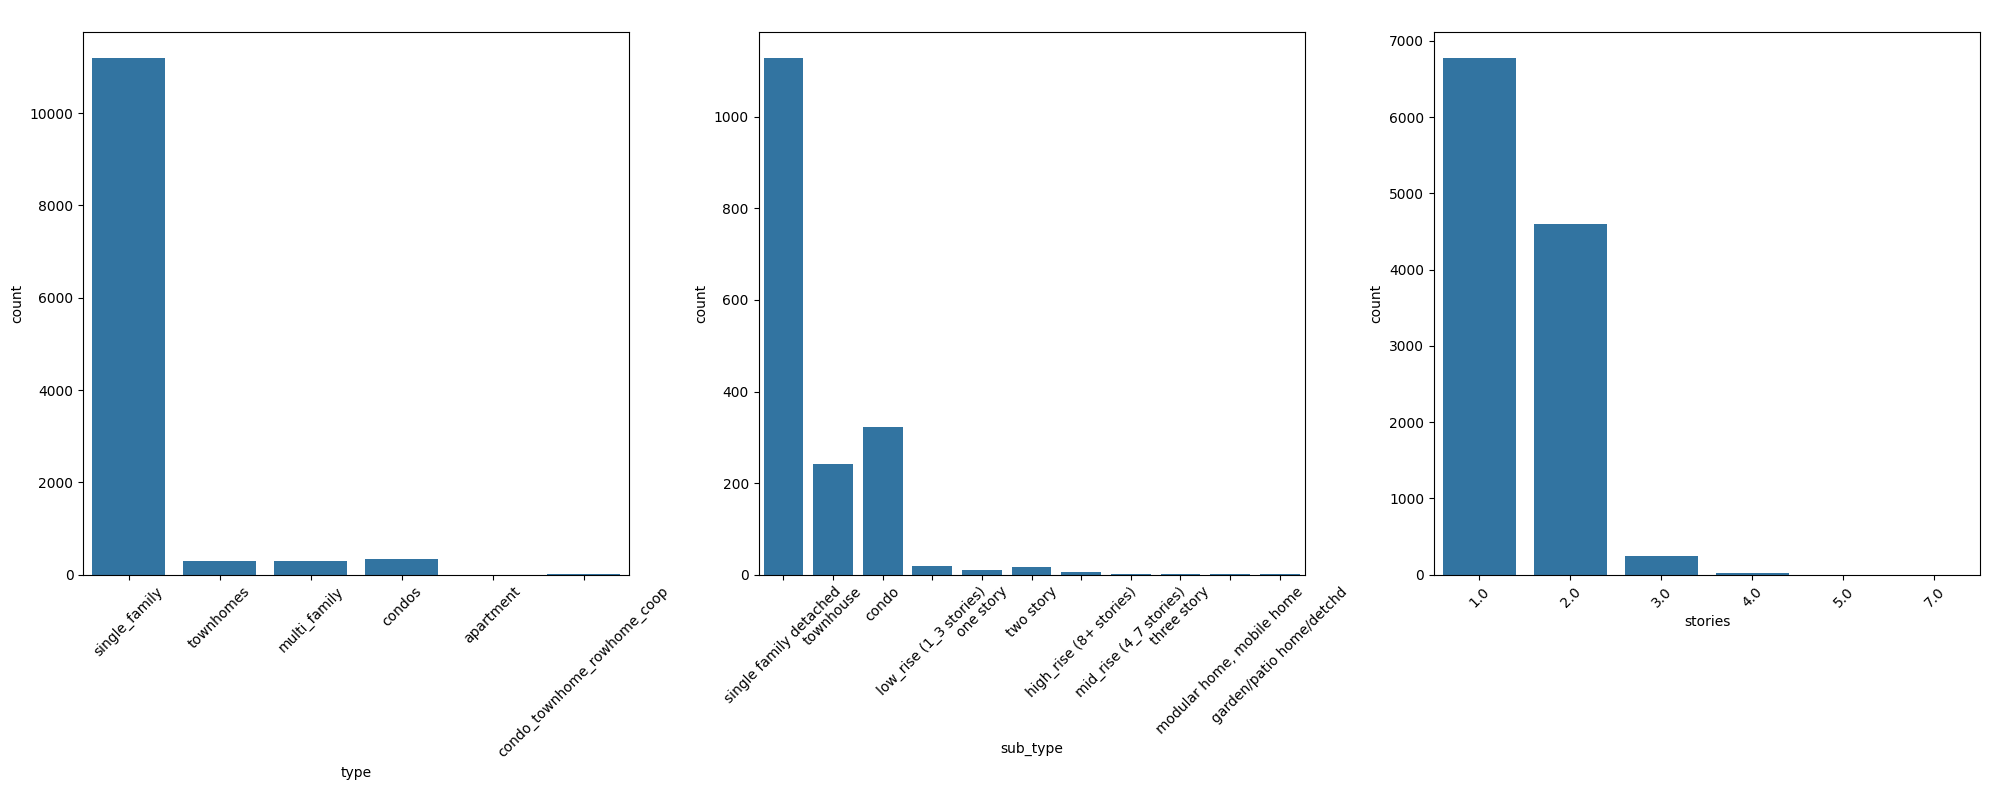

In [17]:
cat_cols = ['type', 'sub_type', 'stories']

plt.figure(figsize=(20,8))
for i, col in enumerate(cat_cols):
    plt.subplot(1,3,i+1)
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(f'Count of {col}', color='white')
plt.tight_layout()
plt.show()

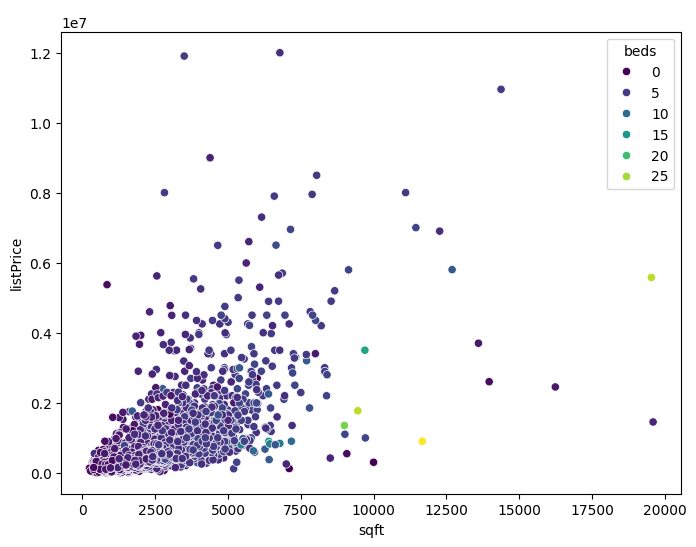

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='sqft', y='listPrice', hue='beds', palette='viridis')
plt.title('Price vs Sqft', color='white')
plt.show()

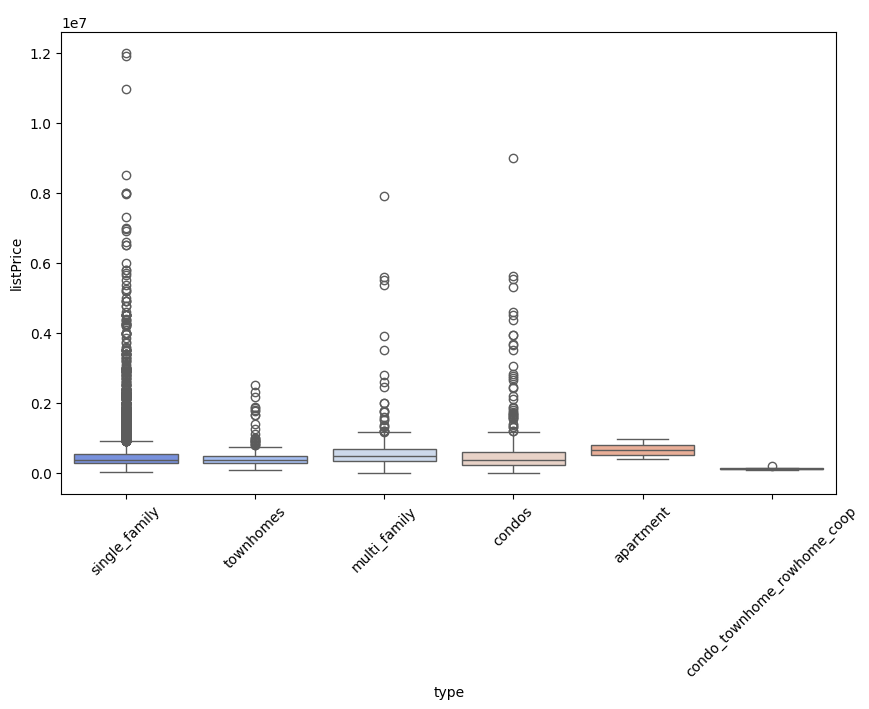

In [19]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='type', y='listPrice', palette='coolwarm')
plt.xticks(rotation=45)
plt.title('Price Distribution by Property Type', color='white')
plt.show()

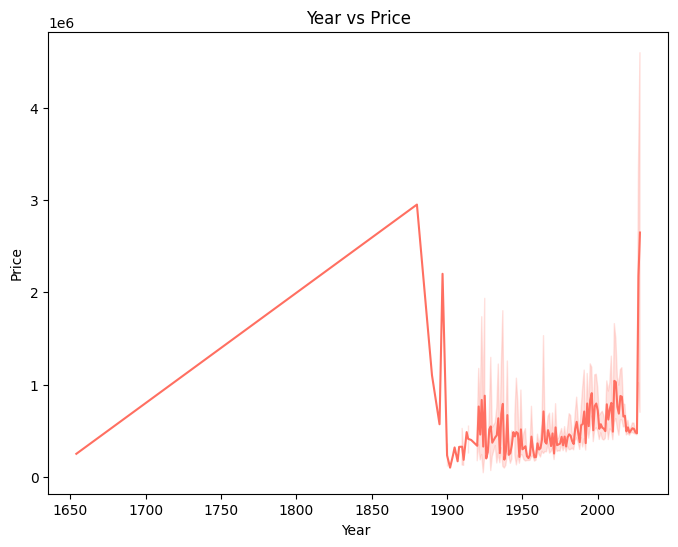

In [20]:
plt.figure(figsize=(8,6))
sns.lineplot(data=df, x='year_built', y='listPrice', color='#FF6F61')
plt.title('Year vs Price')
plt.xlabel("Year ")
plt.ylabel("Price")
plt.show()

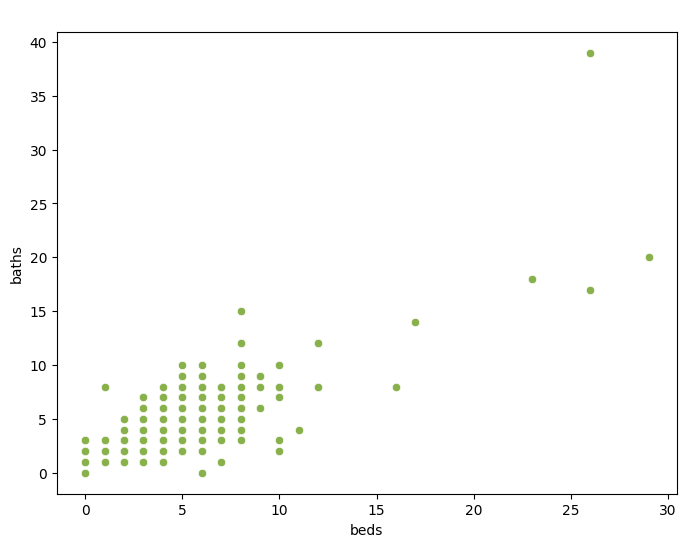

In [21]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='beds', y='baths', color='#88B04B')
plt.title('Beds vs Baths', color='white')
plt.show()

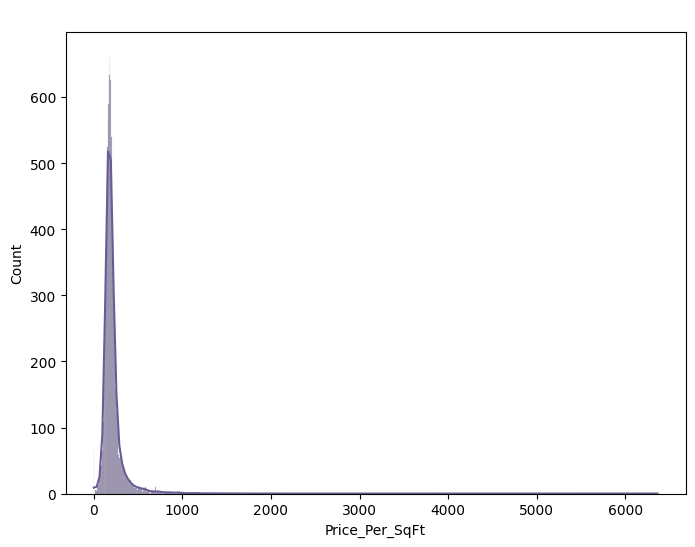

In [22]:
plt.figure(figsize=(8,6))
sns.histplot(df['Price_Per_SqFt'], kde=True, color='#6B5B95')
plt.title('Price Per SqFt Distribution', color='white')
plt.show()

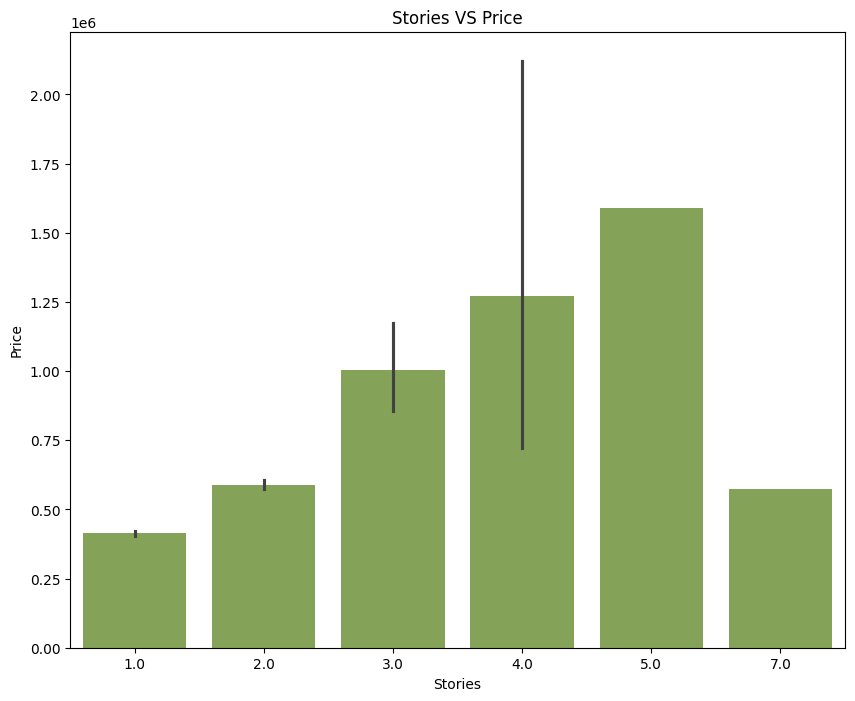

In [23]:
plt.figure(figsize=(10,8))
sns.barplot(df , x='stories' , y='listPrice' , color='#88B04B')
plt.title("Stories VS Price")
plt.xlabel("Stories")
plt.ylabel("Price")
plt.show()

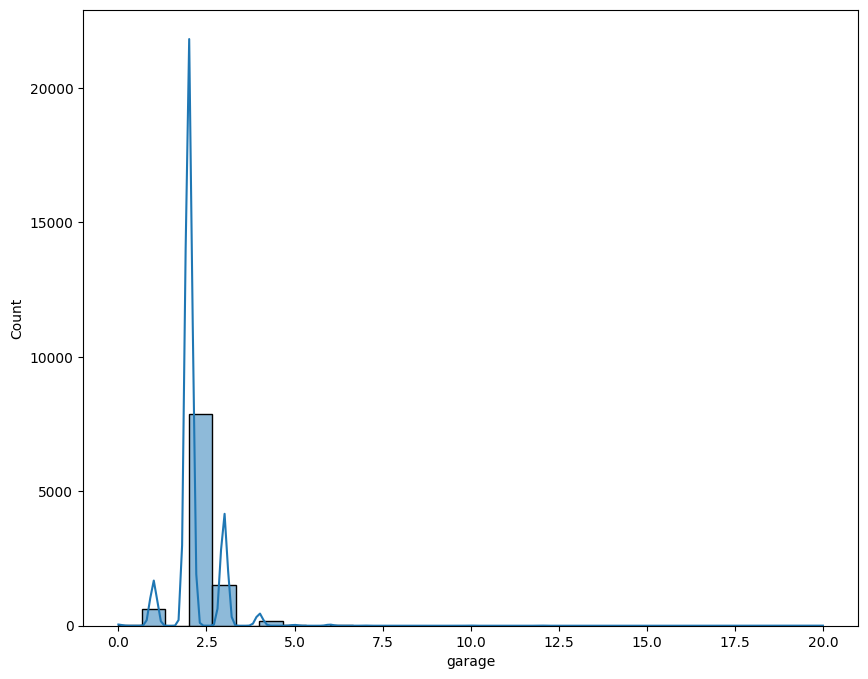

In [24]:
plt.figure(figsize=(10,8))
sns.histplot(df , x="garage" , kde=True , bins=30)
plt.show()

<Figure size 1000x800 with 0 Axes>

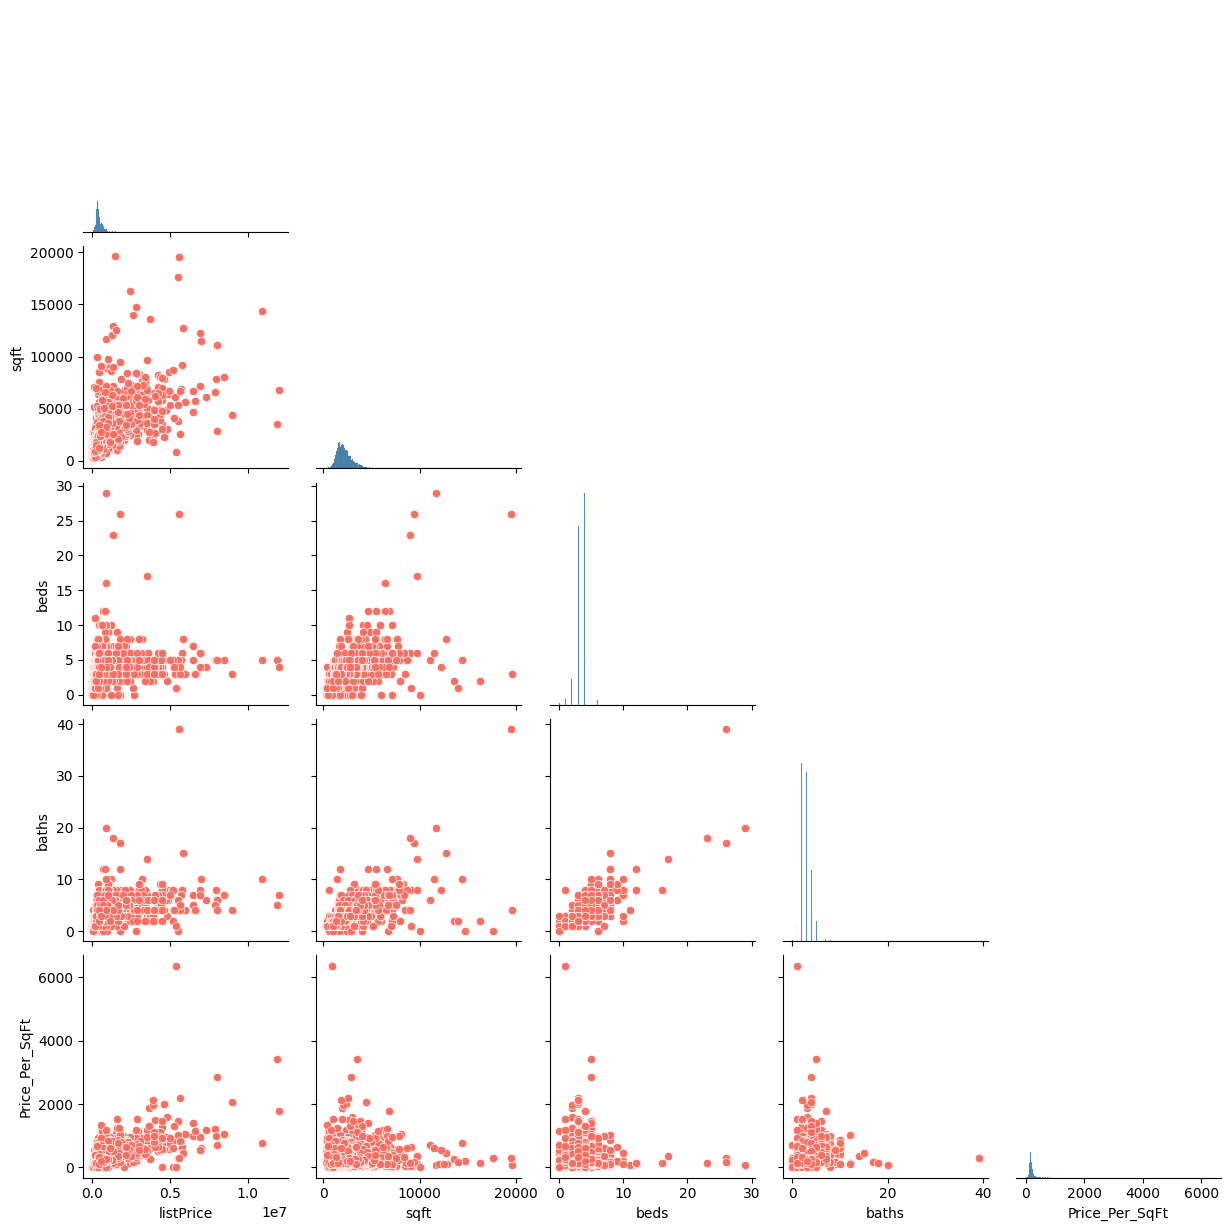

In [25]:
plt.figure(figsize=(10,8))
sns.pairplot(df[['listPrice', 'sqft', 'beds', 'baths', 'Price_Per_SqFt']], 
             corner=True, plot_kws={'color': '#FF6F61'})
plt.show()

# **Preprocessing**

In [26]:
df['type'].value_counts()

type
single_family                  11188
condos                           340
multi_family                     302
townhomes                        293
condo_townhome_rowhome_coop       11
apartment                          3
Name: count, dtype: int64

In [27]:
df['sub_type'].value_counts()

sub_type
single family detached       1128
condo                         322
townhouse                     241
low_rise (1_3 stories)         20
two story                      16
one story                      10
high_rise (8+ stories)          6
three story                     2
modular home, mobile home       2
mid_rise (4_7 stories)          1
garden/patio home/detchd        1
Name: count, dtype: int64

In [28]:
df[df['sub_type'].isna()]

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,Price_Per_SqFt
0,single_family,NaN,Experience The Best Of North Texas Living In T...,499000.0,2040.0,2.0,3.0,3.0,2.0,2.0,2.0,2021.0,244.61
1,single_family,NaN,"Welcome home to [Redacted Entity], [Redacted E...",494500.0,3674.0,2.0,6.0,4.0,3.0,3.0,NaN,2025.0,134.59
2,single_family,NaN,Welcome to this beautiful home located in [Red...,229000.0,1650.0,2.0,3.0,3.0,2.0,2.0,2.0,2020.0,138.79
3,single_family,NaN,"Welcome to [Redacted Entity] - where style, co...",260000.0,1741.0,1.0,3.0,2.0,2.0,2.0,2.0,2005.0,149.34
5,single_family,NaN,This inviting property highlights the best of ...,332950.0,2344.0,2.0,4.0,NaN,2.0,2.0,2.0,NaN,142.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12131,single_family,NaN,Welcome to effortless living in the heart of [...,139000.0,963.0,1.0,2.0,1.0,1.0,1.0,NaN,1983.0,144.34
12133,single_family,NaN,Welcome home to this charming farmhouse-style ...,459900.0,2414.0,2.0,4.0,3.0,2.0,2.0,2.0,2021.0,190.51
12134,single_family,NaN,"Welcome to [Redacted Entity], a beautifully ma...",405000.0,3428.0,2.0,4.0,4.0,3.0,3.0,2.0,1984.0,118.14
12135,single_family,NaN,BEACHSIDE GEM HAS IT ALL! Lovely 3/2 in the he...,399000.0,1260.0,1.0,3.0,2.0,2.0,2.0,1.0,2008.0,316.67


In [29]:
df1 = df[df['sub_type'].notna()]
df1

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,Price_Per_SqFt
4,single_family,single family detached,***READY NOW*** Discover this stunning new con...,334990.0,2255.0,2.0,4.0,4.0,3.0,3.0,2.0,2025.0,148.55
19,townhomes,townhouse,"Located in New gated community, this corner un...",268000.0,1251.0,2.0,4.0,3.0,3.0,3.0,NaN,2025.0,214.23
25,condos,condo,Fully furnished one bedroom in calm and peacef...,169000.0,732.0,1.0,1.0,1.0,1.0,1.0,NaN,1984.0,230.87
29,single_family,single family detached,[Redacted Entity] is a custom-built 5-bed/5.5-...,595000.0,3002.0,1.0,5.0,6.0,5.0,5.0,NaN,2010.0,198.20
30,single_family,single family detached,Where [Redacted Entity] meets relaxation! This...,1200000.0,2525.0,2.0,4.0,4.0,3.0,3.0,NaN,2011.0,475.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12109,condos,condo,This detached end-unit lives like a single-fam...,525000.0,1938.0,2.0,3.0,3.0,2.0,2.0,2.0,2018.0,270.90
12111,single_family,single family detached,[Redacted Entity].,997900.0,3578.0,2.0,5.0,7.0,5.0,5.0,3.0,2025.0,278.90
12113,condos,condo,Take advantage of this incredible opportunity ...,349000.0,1027.0,1.0,1.0,1.0,1.0,1.0,1.0,1998.0,339.82
12118,single_family,single family detached,"Located in [Redacted Entity], this property of...",109900.0,865.0,1.0,2.0,1.0,1.0,1.0,NaN,1911.0,127.05


In [30]:
df1[df1['sub_type'] == 'garden/patio home/detchd']

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,Price_Per_SqFt
11978,single_family,garden/patio home/detchd,Last chance to own a brand new [Redacted Entit...,822691.0,2552.0,1.0,3.0,4.0,3.0,3.0,3.0,2026.0,322.37


In [31]:
df['stories'].agg(['mean' , 'min' , 'max'])

mean    1.442562
min     1.000000
max     7.000000
Name: stories, dtype: float64

In [32]:
df[df['stories'] == 7]

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,Price_Per_SqFt
6919,condos,condo,"Rising at the intersection of culture, creativ...",575000.0,1491.0,7.0,2.0,3.0,2.0,2.0,2.0,2026.0,385.65


In [33]:
df[df['stories'].isna()]

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,Price_Per_SqFt
6,single_family,NaN,Welcome to [Redacted Entity] in the Heart of [...,399990.0,1944.0,NaN,4.0,2.0,2.0,2.0,3.0,NaN,205.76
18,single_family,NaN,HISTORY MEETS WIDE OPEN SPACES! This home sits...,399900.0,3563.0,NaN,4.0,4.0,3.0,3.0,4.0,2009.0,112.24
22,single_family,NaN,"Great opportunity in [Redacted Entity], [Redac...",130000.0,1188.0,NaN,3.0,2.0,1.0,2.0,2.0,1957.0,109.43
23,multi_family,NaN,Nicest duplex in [Redacted Entity]! Well kept ...,1595.0,1312.0,NaN,0.0,NaN,NaN,NaN,NaN,2004.0,1.22
24,single_family,NaN,Want a COOL LAKE VIEW? PRICE REDUCTION! Look a...,519000.0,1887.0,NaN,3.0,2.0,2.0,2.0,NaN,1997.0,275.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11929,single_family,NaN,This is a site to build your forever home just...,22500.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.00
11958,condo_townhome_rowhome_coop,condo,Whether you want to enjoy a getaway for yourse...,115000.0,588.0,NaN,1.0,1.0,1.0,1.0,NaN,NaN,195.58
11961,condos,condo,Amazing and immaculate District 12 condo!! Mak...,175000.0,958.0,NaN,2.0,2.0,2.0,2.0,NaN,1983.0,182.67
12059,single_family,NaN,[Redacted Entity] family compound on 5 acres a...,2995000.0,5394.0,NaN,8.0,9.0,9.0,9.0,NaN,2017.0,555.25


In [34]:
mapping = {
    'one story': 1,
    'two story': 2,
    'three story': 3,
    'low_rise (1_3 stories)': 2,
    'mid_rise (4_7 stories)': 4,
    'high_rise (8+ stories)': 8
}

In [35]:
df['stories'] = df['stories'].fillna(df['sub_type'].map(mapping))

In [36]:
df[df['stories'].isna()]

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,Price_Per_SqFt
6,single_family,NaN,Welcome to [Redacted Entity] in the Heart of [...,399990.0,1944.0,NaN,4.0,2.0,2.0,2.0,3.0,NaN,205.76
18,single_family,NaN,HISTORY MEETS WIDE OPEN SPACES! This home sits...,399900.0,3563.0,NaN,4.0,4.0,3.0,3.0,4.0,2009.0,112.24
22,single_family,NaN,"Great opportunity in [Redacted Entity], [Redac...",130000.0,1188.0,NaN,3.0,2.0,1.0,2.0,2.0,1957.0,109.43
23,multi_family,NaN,Nicest duplex in [Redacted Entity]! Well kept ...,1595.0,1312.0,NaN,0.0,NaN,NaN,NaN,NaN,2004.0,1.22
24,single_family,NaN,Want a COOL LAKE VIEW? PRICE REDUCTION! Look a...,519000.0,1887.0,NaN,3.0,2.0,2.0,2.0,NaN,1997.0,275.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11929,single_family,NaN,This is a site to build your forever home just...,22500.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.00
11958,condo_townhome_rowhome_coop,condo,Whether you want to enjoy a getaway for yourse...,115000.0,588.0,NaN,1.0,1.0,1.0,1.0,NaN,NaN,195.58
11961,condos,condo,Amazing and immaculate District 12 condo!! Mak...,175000.0,958.0,NaN,2.0,2.0,2.0,2.0,NaN,1983.0,182.67
12059,single_family,NaN,[Redacted Entity] family compound on 5 acres a...,2995000.0,5394.0,NaN,8.0,9.0,9.0,9.0,NaN,2017.0,555.25


In [37]:
df_condo = df[df['sub_type'] == 'condo']

In [38]:
df_condo[['stories', 'beds']]

,stories,beds
25,1.0,1.0
43,1.0,1.0
99,NaN,4.0
167,2.0,2.0
174,3.0,3.0
...,...,...
12089,2.0,3.0
12101,1.0,1.0
12109,2.0,3.0
12113,1.0,1.0


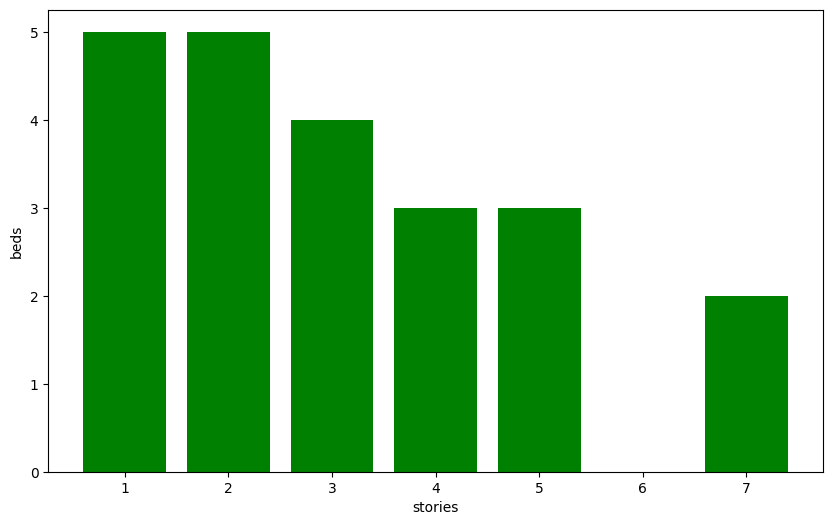

In [39]:
plt.figure(figsize=(10,6))
plt.bar(df_condo['stories'] ,df_condo['beds'] ,color='green')
plt.xlabel('stories')
plt.ylabel('beds')
plt.show()

In [40]:
df.drop("sub_type" , axis=1 , inplace=True)

In [41]:
df['stories'].mean()

np.float64(1.446587791495199)

In [42]:
df['stories'] = df['stories'].fillna(df.groupby('type')['stories'].transform(lambda x: x.mode()[0]))

In [43]:
df

,type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,Price_Per_SqFt
0,single_family,Experience The Best Of North Texas Living In T...,499000.0,2040.0,2.0,3.0,3.0,2.0,2.0,2.0,2021.0,244.61
1,single_family,"Welcome home to [Redacted Entity], [Redacted E...",494500.0,3674.0,2.0,6.0,4.0,3.0,3.0,NaN,2025.0,134.59
2,single_family,Welcome to this beautiful home located in [Red...,229000.0,1650.0,2.0,3.0,3.0,2.0,2.0,2.0,2020.0,138.79
3,single_family,"Welcome to [Redacted Entity] - where style, co...",260000.0,1741.0,1.0,3.0,2.0,2.0,2.0,2.0,2005.0,149.34
4,single_family,***READY NOW*** Discover this stunning new con...,334990.0,2255.0,2.0,4.0,4.0,3.0,3.0,2.0,2025.0,148.55
...,...,...,...,...,...,...,...,...,...,...,...,...
12132,condos,Welcome to [Redacted Entity] in the Heart of [...,222000.0,1495.0,2.0,2.0,3.0,2.0,2.0,NaN,1968.0,148.49
12133,single_family,Welcome home to this charming farmhouse-style ...,459900.0,2414.0,2.0,4.0,3.0,2.0,2.0,2.0,2021.0,190.51
12134,single_family,"Welcome to [Redacted Entity], a beautifully ma...",405000.0,3428.0,2.0,4.0,4.0,3.0,3.0,2.0,1984.0,118.14
12135,single_family,BEACHSIDE GEM HAS IT ALL! Lovely 3/2 in the he...,399000.0,1260.0,1.0,3.0,2.0,2.0,2.0,1.0,2008.0,316.67


In [44]:
df[df['Price_Per_SqFt'].isna()]

,type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,Price_Per_SqFt
2318,single_family,"A homeowner favorite, the Princeton II welcome...",NaN,2841.0,2.0,4.0,3.0,2.0,2.0,2.0,NaN,NaN
2537,single_family,"[Redacted Entity], a beautifully crafted home ...",NaN,2341.0,1.0,4.0,4.0,3.0,3.0,2.0,NaN,NaN


In [45]:
df['Price_Per_SqFt'] = df['Price_Per_SqFt'].fillna(df['Price_Per_SqFt'].mean())

In [46]:
df['listPrice'] = df['listPrice'].fillna(df['listPrice'].mean())

# **NLP & KNN**

In [47]:
number_map = {
    "one": 1,
    "two": 2,
    "three": 3,
    "four": 4,
    "five": 5,
    "six": 6,
    "seven": 7,
    "eight": 8,
    "nine": 9,
    "ten": 10
}

In [48]:
import spacy

nlp = spacy.load("en_core_web_sm")
def convert_to_number(token):
    try:
        return float(token)
    except:
        return float(number_map.get(token, np.nan))

In [49]:
def extract_beds(text):
    doc = nlp(text.lower())

    for i, token in enumerate(doc):
        if token.like_num or token.text in number_map:

            value = convert_to_number(token.text)

            if i + 1 < len(doc):
                if doc[i + 1].text in ["bed", "beds", "bedroom", "bedrooms"]:
                    return value

    return np.nan

In [50]:
def extract_baths(text):
    doc = nlp(text.lower())

    for i, token in enumerate(doc):
        if token.like_num or token.text in number_map:

            value = convert_to_number(token.text)

            if i + 1 < len(doc):
                if doc[i + 1].text in ["bath", "baths", "bathroom", "ba"]:
                    return value

    return np.nan

In [51]:
df['beds'] = df['beds'].fillna(df['text'].apply(extract_beds))
df['baths'] = df['baths'].fillna(df['text'].apply(extract_baths))

In [52]:
from sklearn.impute import KNNImputer

features = ['beds','baths','garage','year_built','sqft']

imputer = KNNImputer(n_neighbors=2)

df[features] = imputer.fit_transform(df[features])

In [53]:
df[features]

,beds,baths,garage,year_built,sqft
0,3.0,3.0,2.0,2021.0,2040.0
1,6.0,4.0,2.0,2025.0,3674.0
2,3.0,3.0,2.0,2020.0,1650.0
3,3.0,2.0,2.0,2005.0,1741.0
4,4.0,4.0,2.0,2025.0,2255.0
...,...,...,...,...,...
12132,2.0,3.0,1.5,1968.0,1495.0
12133,4.0,3.0,2.0,2021.0,2414.0
12134,4.0,4.0,2.0,1984.0,3428.0
12135,3.0,2.0,1.0,2008.0,1260.0


In [54]:
df.isnull().sum()

type                 0
text                 0
listPrice            0
sqft                 0
stories              0
beds                 0
baths                0
baths_full         149
baths_full_calc    146
garage               0
year_built           0
Price_Per_SqFt       0
dtype: int64

In [55]:
df[df['Price_Per_SqFt'] ==0]

,type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,Price_Per_SqFt
71,single_family,COMING SOON! No [Redacted Entity] perfectly si...,495767.0,2072.0,1.0,4.0,2.0,2.0,2.0,2.0,2021.5,0.0
185,single_family,Beautiful 12.81 acres in the premier [Redacted...,265000.0,724.0,1.0,0.0,1.5,NaN,NaN,3.5,1965.5,0.0
201,single_family,Welcome to 2404 Juniper in Amarillo's highly s...,309000.0,1561.5,1.0,3.0,2.0,2.0,2.0,2.0,1953.0,0.0
849,single_family,Be the first to own this brand-new custom home...,619000.0,3520.5,1.0,4.0,4.0,3.0,3.0,2.0,2024.0,0.0
1666,single_family,COME BUILD YOUR FUTURE HOME OR LET [Redacted E...,30000.0,724.0,1.0,0.0,1.5,NaN,NaN,3.5,1965.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
11867,single_family,It's not too late for to enjoy this summer. Co...,898000.0,3542.0,2.0,4.0,5.0,4.0,4.0,2.5,2025.0,0.0
11929,single_family,This is a site to build your forever home just...,22500.0,3228.5,1.0,0.0,0.0,NaN,NaN,5.0,2023.0,0.0
11970,multi_family,Well maintained duplex in the heart of [Redact...,229000.0,1230.0,1.0,2.0,1.0,1.0,1.0,1.5,1982.0,0.0
12091,single_family,"Lovely 4 bedroom 2 full bath, recently remodel...",209900.0,2673.0,1.0,4.0,2.0,2.0,2.0,2.0,1970.0,0.0


In [56]:
df['Price_Per_SqFt'] = df['Price_Per_SqFt'].replace({0.0 : np.nan})

In [57]:
df['Price_Per_SqFt'] = df['Price_Per_SqFt'].fillna(df['listPrice'] / df['sqft'])

In [58]:
df[df['baths_full'].notna()]

,type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,Price_Per_SqFt
0,single_family,Experience The Best Of North Texas Living In T...,499000.0,2040.0,2.0,3.0,3.0,2.0,2.0,2.0,2021.0,244.61
1,single_family,"Welcome home to [Redacted Entity], [Redacted E...",494500.0,3674.0,2.0,6.0,4.0,3.0,3.0,2.0,2025.0,134.59
2,single_family,Welcome to this beautiful home located in [Red...,229000.0,1650.0,2.0,3.0,3.0,2.0,2.0,2.0,2020.0,138.79
3,single_family,"Welcome to [Redacted Entity] - where style, co...",260000.0,1741.0,1.0,3.0,2.0,2.0,2.0,2.0,2005.0,149.34
4,single_family,***READY NOW*** Discover this stunning new con...,334990.0,2255.0,2.0,4.0,4.0,3.0,3.0,2.0,2025.0,148.55
...,...,...,...,...,...,...,...,...,...,...,...,...
12132,condos,Welcome to [Redacted Entity] in the Heart of [...,222000.0,1495.0,2.0,2.0,3.0,2.0,2.0,1.5,1968.0,148.49
12133,single_family,Welcome home to this charming farmhouse-style ...,459900.0,2414.0,2.0,4.0,3.0,2.0,2.0,2.0,2021.0,190.51
12134,single_family,"Welcome to [Redacted Entity], a beautifully ma...",405000.0,3428.0,2.0,4.0,4.0,3.0,3.0,2.0,1984.0,118.14
12135,single_family,BEACHSIDE GEM HAS IT ALL! Lovely 3/2 in the he...,399000.0,1260.0,1.0,3.0,2.0,2.0,2.0,1.0,2008.0,316.67


In [59]:
df[df['baths_full'].isna()]

,type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,Price_Per_SqFt
23,multi_family,Nicest duplex in [Redacted Entity]! Well kept ...,1595.0,1312.0,1.0,0.0,2.0,NaN,NaN,2.0,2004.0,1.220000
34,multi_family,Brand [Redacted Entity]. Exceptional investmen...,469000.0,4052.0,1.0,3.5,4.0,NaN,NaN,2.0,2025.0,115.750000
63,multi_family,Income-producing fourplex in a highly accessib...,500000.0,4242.0,1.0,3.0,5.5,NaN,NaN,2.0,2025.0,117.870000
185,single_family,Beautiful 12.81 acres in the premier [Redacted...,265000.0,724.0,1.0,0.0,1.5,NaN,NaN,3.5,1965.5,366.022099
272,multi_family,Just steps from [Redacted Entity] and a short ...,670000.0,2688.0,2.0,3.0,2.0,NaN,NaN,2.0,1985.0,249.260000
...,...,...,...,...,...,...,...,...,...,...,...,...
11628,multi_family,"Brand-new, modern 3-bedroom, 2-bath units in a...",545000.0,4200.0,1.0,3.5,3.5,NaN,NaN,2.5,2026.0,129.760000
11740,single_family,"Five build-ready lots from 0.50 to 0.78 acres,...",110000.0,724.0,1.0,0.0,1.5,NaN,NaN,3.5,1965.5,151.933702
11745,condos,"Garage [Redacted Entity], the ultimate destina...",175000.0,3285.0,1.0,0.0,6.0,NaN,NaN,16.0,2025.0,53.272451
11817,multi_family,New multifamily development for sale. 6 Total ...,760000.0,5088.0,2.0,2.0,5.0,NaN,NaN,2.0,2025.0,149.370000


In [60]:
df['year_built'].value_counts()

year_built
2025.0    2488
2026.0    1645
2022.0     799
2024.0     686
2023.0     653
          ... 
1977.5       1
1904.0       1
1996.5       1
1960.5       1
1905.0       1
Name: count, Length: 187, dtype: int64

In [61]:
df['beds'] = df['beds'].replace({0 : np.nan})
df['baths'] = df['baths'].replace({0 : np.nan})

In [62]:
df['beds'] = df['beds'].fillna(df['beds'].mean())
df['baths'] = df['baths'].fillna(df['baths'].mean())

In [63]:
df['baths_full'] = df['baths_full'].fillna(df['baths'] - 1)
df['baths_full'] = df['baths_full'].replace(0, 1)

In [64]:
df.drop(columns=['baths_full_calc'], inplace=True)

In [65]:
df['stories'] = df['stories'].astype(int)
df['beds'] = df['beds'].astype(int)
df['baths'] = df['baths'].astype(int)
df['baths_full'] = df['baths_full'].astype(int)
df['garage'] = df['garage'].astype(int)
df['year_built'] = df['year_built'].astype(int)

In [66]:
df.isnull().sum()

type              0
text              0
listPrice         0
sqft              0
stories           0
beds              0
baths             0
baths_full        0
garage            0
year_built        0
Price_Per_SqFt    0
dtype: int64

# **Feature Enginner**

In [67]:
df = df.rename(columns={
    'type' : 'Type',
    'text' : 'Text',
    'listPrice': 'Price',
    'sqft': 'Sqft',
    'baths': 'Bathroom',
    'baths_full': 'Bathroom Full',
    'garage': 'Garage',
    'year_built': 'Year',
    'Price_Per_SqFt': 'Price_SqFt' ,
    'stories' : 'Stories'
})

In [68]:
df

,Type,Text,Price,Sqft,Stories,beds,Bathroom,Bathroom Full,Garage,Year,Price_SqFt
0,single_family,Experience The Best Of North Texas Living In T...,499000.0,2040.0,2,3,3,2,2,2021,244.61
1,single_family,"Welcome home to [Redacted Entity], [Redacted E...",494500.0,3674.0,2,6,4,3,2,2025,134.59
2,single_family,Welcome to this beautiful home located in [Red...,229000.0,1650.0,2,3,3,2,2,2020,138.79
3,single_family,"Welcome to [Redacted Entity] - where style, co...",260000.0,1741.0,1,3,2,2,2,2005,149.34
4,single_family,***READY NOW*** Discover this stunning new con...,334990.0,2255.0,2,4,4,3,2,2025,148.55
...,...,...,...,...,...,...,...,...,...,...,...
12132,condos,Welcome to [Redacted Entity] in the Heart of [...,222000.0,1495.0,2,2,3,2,1,1968,148.49
12133,single_family,Welcome home to this charming farmhouse-style ...,459900.0,2414.0,2,4,3,2,2,2021,190.51
12134,single_family,"Welcome to [Redacted Entity], a beautifully ma...",405000.0,3428.0,2,4,4,3,2,1984,118.14
12135,single_family,BEACHSIDE GEM HAS IT ALL! Lovely 3/2 in the he...,399000.0,1260.0,1,3,2,2,1,2008,316.67


In [69]:
df = pd.get_dummies(df, columns=['Type'])

In [70]:
x = df.drop(columns=['Price' , 'Text'])
y = df['Price']

In [71]:
scaler = RobustScaler()
x = scaler.fit_transform(x)

In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

x_text = tfidf.fit_transform(df['Text'])

In [73]:
x

array([[-0.04198473,  1.        , -1.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 1.51717557,  1.        ,  2.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.41412214,  1.        , -1.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 1.28244275,  1.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.78625954,  0.        , -1.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.61068702,  1.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]])

In [74]:
y

0        499000.0
1        494500.0
2        229000.0
3        260000.0
4        334990.0
           ...   
12132    222000.0
12133    459900.0
12134    405000.0
12135    399000.0
12136    545000.0
Name: Price, Length: 12137, dtype: float64

In [75]:
X_final = scipy.sparse.hstack([x_text, x])

# **Spliting**

In [76]:
x_train , x_test, y_train , y_test = train_test_split(X_final , y , test_size=0.2 , random_state=42 , shuffle=True)

# **Bulid Model**

In [77]:
ridge_reg= Ridge(alpha=50, max_iter=100, tol=0.1)
ridge_reg.fit(x_train, y_train)

Ridge(alpha=50, max_iter=100, tol=0.1)

In [78]:
ridge_reg.score(x_train, y_train)

0.7442885719242801

In [79]:
ridge_reg.score(x_test, y_test)

0.7683168431726022

In [80]:
model = SVR()
parameter = {'C' : [50 ,100, 200 , 500] ,
            'kernel' : ['linear' , 'poly' , 'rbf'] ,
            'gamma' : ['auto' , 'scale' , 0.1 , 0.01],
            'epsilon' : [0.1 , 0.01]}

models = GridSearchCV(model , parameter , cv=5, scoring='r2')

In [81]:
models.fit(x_train , y_train)

GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [50, 100, 200, 500], 'epsilon': [0.1, 0.01],
                         'gamma': ['auto', 'scale', 0.1, 0.01],
                         'kernel': ['linear', 'poly', 'rbf']},
             scoring='r2')

# **Evaluation Metrics**

In [82]:
print("🔍 Best parameters for SVM:", models.best_params_)
print(f"✅ Best cross-validation accuracy: {models.best_score_:.4f}")

🔍 Best parameters for SVM: {'C': 500, 'epsilon': 0.1, 'gamma': 'auto', 'kernel': 'linear'}
✅ Best cross-validation accuracy: 0.7450


In [83]:
models.score(x_train , y_train)

0.751875912709234

In [84]:
y_pred = models.predict(x_test)

In [86]:
print(r2_score(y_test, y_pred))

0.799366924760525
